## Huzaifa Rehman
## 24I-2554

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file = "Sample - Superstore.csv" if os.path.exists("Sample - Superstore.csv") else "/mnt/data/Sample - Superstore.csv"
df = pd.read_csv(file, encoding="latin1")
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
df = df.drop_duplicates()

df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Task 1

The line chart shows the trend best. The pie chart hides the time trend because it is mainly used for part-to-whole comparisons.


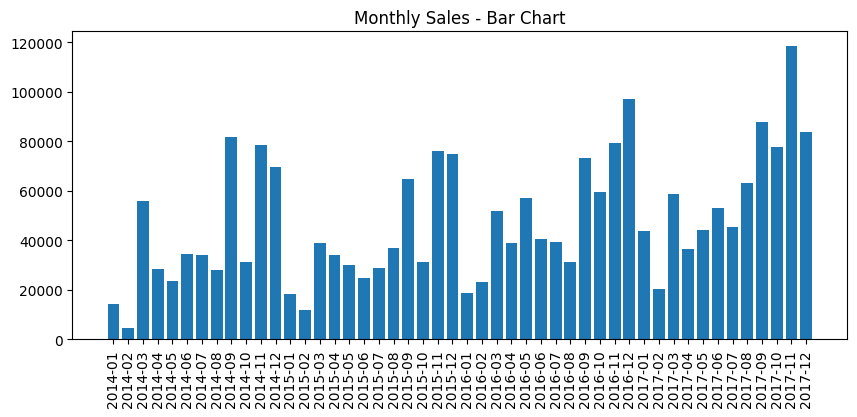

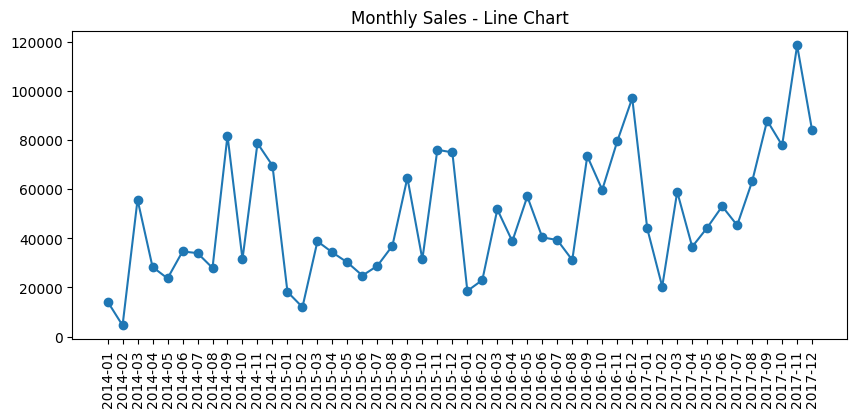

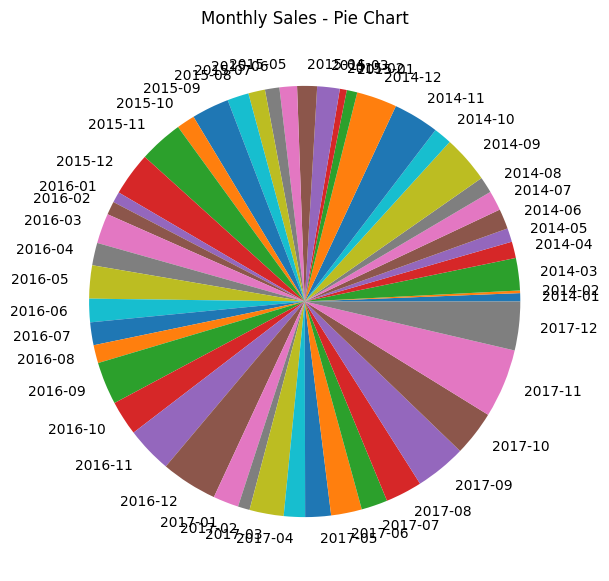

In [2]:
df["Month"] = df["Order Date"].dt.to_period("M").astype(str)
monthly_sales = df.groupby("Month")["Sales"].sum()

plt.figure(figsize=(10,4))
plt.bar(monthly_sales.index, monthly_sales.values)
plt.xticks(rotation=90)
plt.title("Monthly Sales - Bar Chart")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.xticks(rotation=90)
plt.title("Monthly Sales - Line Chart")
plt.show()

plt.figure(figsize=(7,7))
plt.pie(monthly_sales.values, labels=monthly_sales.index)
plt.title("Monthly Sales - Pie Chart")
plt.show()


## Task 2

Top 5 sub-categories: bar chart. It makes category comparisons easy.

Revenue over time: line chart. It shows the trend clearly.

Sales distribution: histogram. It shows the spread of sales values.

Discount and profit: scatter plot. It shows the relationship between the two variables.


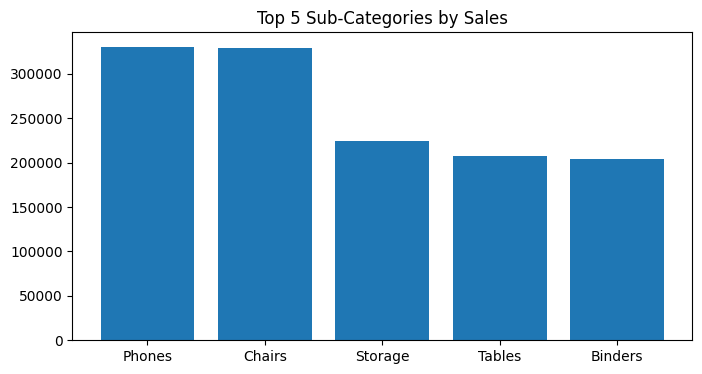

In [3]:
top5 = df.groupby("Sub-Category")["Sales"].sum().nlargest(5)

plt.figure(figsize=(8,4))
plt.bar(top5.index, top5.values)
plt.title("Top 5 Sub-Categories by Sales")
plt.show()


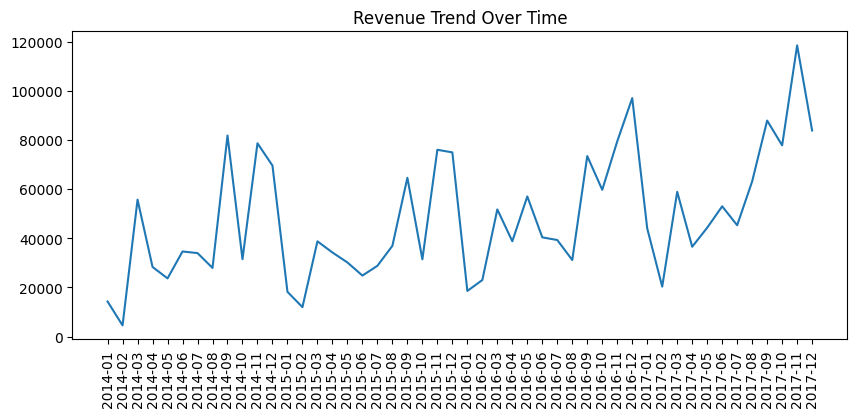

In [4]:
plt.figure(figsize=(10,4))
plt.plot(monthly_sales.index, monthly_sales.values)
plt.xticks(rotation=90)
plt.title("Revenue Trend Over Time")
plt.show()


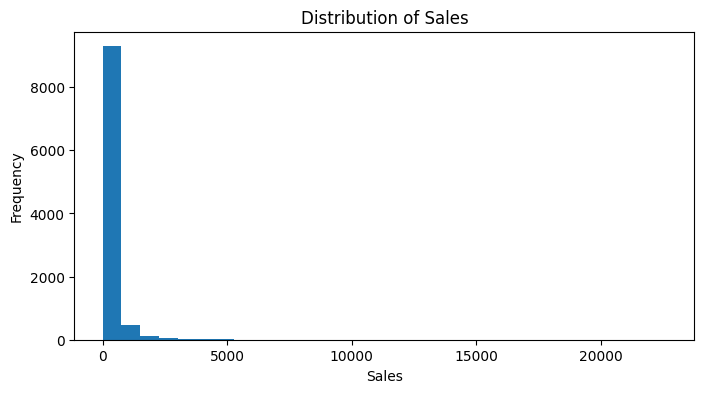

In [5]:
plt.figure(figsize=(8,4))
plt.hist(df["Sales"], bins=30)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()


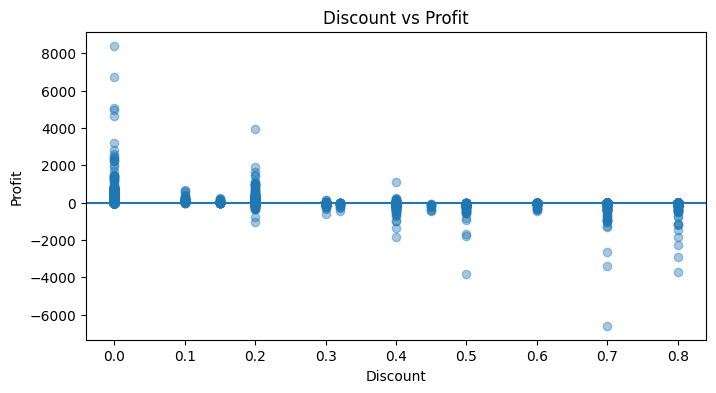

In [6]:
plt.figure(figsize=(8,4))
plt.scatter(df["Discount"], df["Profit"], alpha=0.4)
plt.axhline(0)
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()


## Task 3

Region is categorical, so a categorical palette is used.

The region-category heatmap uses a sequential palette.

Profit uses a diverging palette because it can be positive or negative.


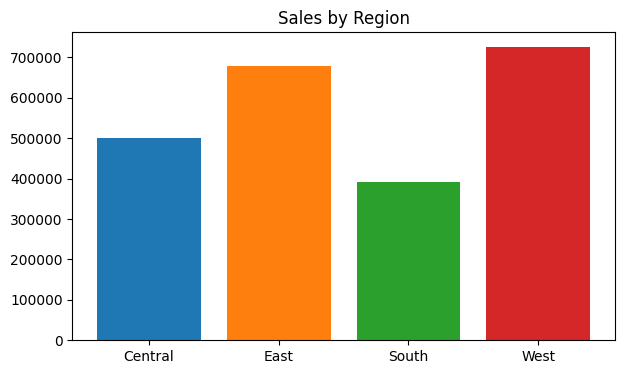

In [7]:
region_sales = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(7,4))
plt.bar(region_sales.index, region_sales.values, color=plt.cm.tab10(range(len(region_sales))))
plt.title("Sales by Region")
plt.show()


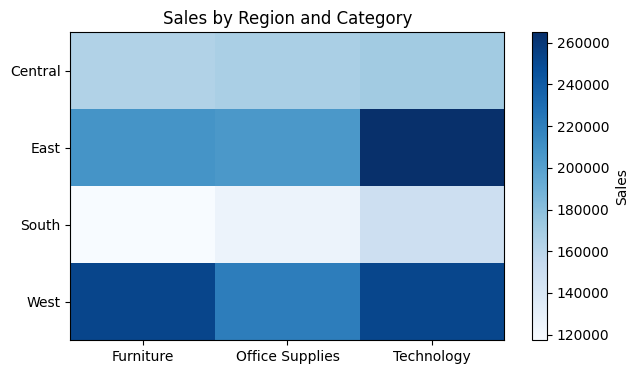

In [8]:
region_category = pd.pivot_table(
    df, values="Sales", index="Region", columns="Category", aggfunc="sum"
)

plt.figure(figsize=(7,4))
plt.imshow(region_category, cmap="Blues", aspect="auto")
plt.colorbar(label="Sales")
plt.xticks(range(len(region_category.columns)), region_category.columns)
plt.yticks(range(len(region_category.index)), region_category.index)
plt.title("Sales by Region and Category")
plt.show()


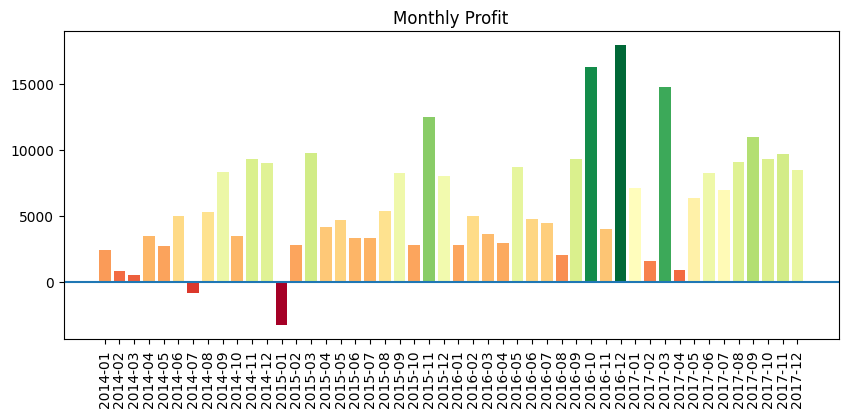

In [9]:
monthly_profit = df.groupby("Month")["Profit"].sum()

plt.figure(figsize=(10,4))
plt.bar(
    monthly_profit.index,
    monthly_profit.values,
    color=plt.cm.RdYlGn(
        (monthly_profit.values - monthly_profit.min()) /
        (monthly_profit.max() - monthly_profit.min())
    )
)
plt.axhline(0)
plt.xticks(rotation=90)
plt.title("Monthly Profit")
plt.show()


## Task 4

The contrast ratio is calculated below. The lab uses 4.5:1 as the AA threshold for text.

Red and green should not be the only way to show loss and gain. Hatching is added in the fixed chart.


In [10]:
def contrast_ratio(c1, c2):
    def lum(c):
        c = np.array(c) / 255
        c = np.where(c <= 0.03928, c / 12.92, ((c + 0.055) / 1.055) ** 2.4)
        return 0.2126*c[0] + 0.7152*c[1] + 0.0722*c[2]

    a, b = lum(c1), lum(c2)
    return (max(a,b) + 0.05) / (min(a,b) + 0.05)

colors = {
    "Blue": (31,119,180),
    "Orange": (255,127,14),
    "Green": (44,160,44),
    "Red": (214,39,40),
    "Dark gray": (70,70,70)
}

for name, rgb in colors.items():
    ratio = contrast_ratio(rgb, (255,255,255))
    print(name, round(ratio, 2), "PASS" if ratio >= 4.5 else "FAIL")


Blue 4.82 PASS
Orange 2.53 FAIL
Green 3.4 FAIL
Red 5.02 PASS
Dark gray 9.44 PASS


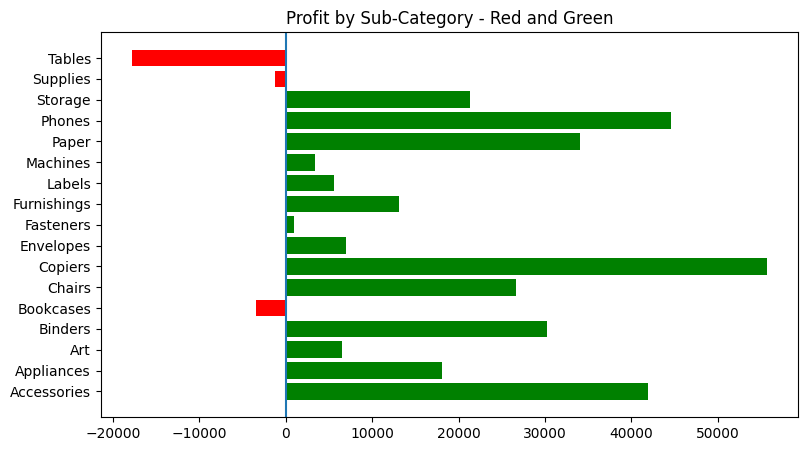

In [11]:
sub_profit = df.groupby("Sub-Category")["Profit"].sum()

plt.figure(figsize=(9,5))
plt.barh(
    sub_profit.index,
    sub_profit.values,
    color=["red" if x < 0 else "green" for x in sub_profit.values]
)
plt.axvline(0)
plt.title("Profit by Sub-Category - Red and Green")
plt.show()


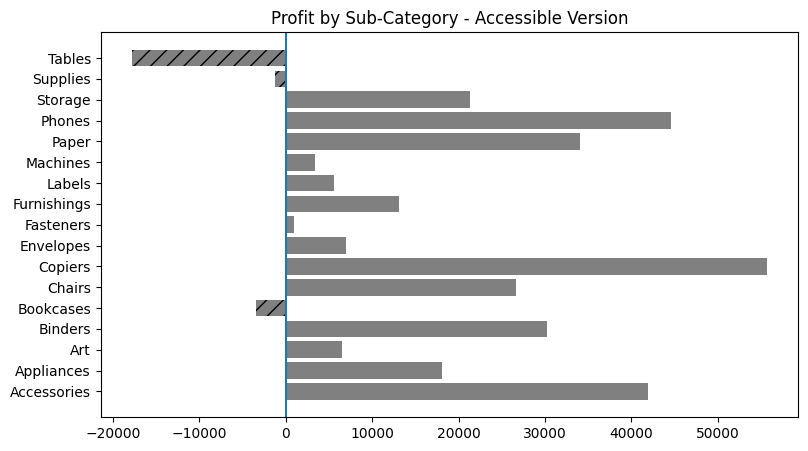

Alt text: Hatched bars show losses and plain bars show gains.


In [12]:
plt.figure(figsize=(9,5))

bars = plt.barh(
    sub_profit.index,
    sub_profit.values,
    color="gray"
)

for bar, value in zip(bars, sub_profit.values):
    if value < 0:
        bar.set_hatch("//")

plt.axvline(0)
plt.title("Profit by Sub-Category - Accessible Version")
plt.show()

print("Alt text: Hatched bars show losses and plain bars show gains.")


## Task 5

Each chart below shows a different misleading technique.


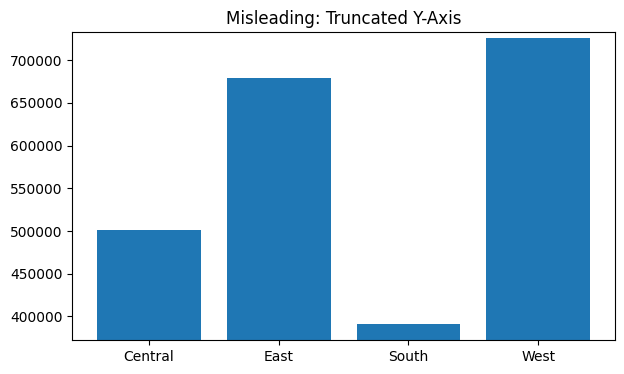

Distortion: truncated y-axis exaggerates differences.


In [13]:
plt.figure(figsize=(7,4))
plt.bar(region_sales.index, region_sales.values)
plt.ylim(region_sales.min()*0.95, region_sales.max()*1.01)
plt.title("Misleading: Truncated Y-Axis")
plt.show()

print("Distortion: truncated y-axis exaggerates differences.")


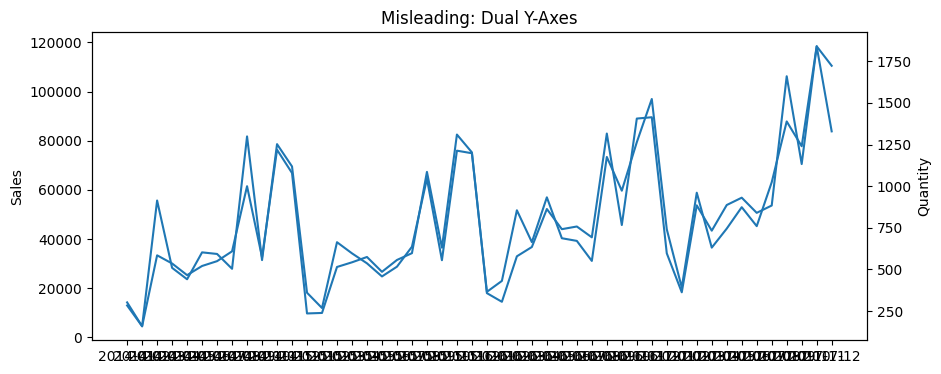

Distortion: dual axes can imply a relationship between unrelated measures.


In [14]:
monthly_quantity = df.groupby("Month")["Quantity"].sum()

fig, ax1 = plt.subplots(figsize=(10,4))
ax2 = ax1.twinx()

ax1.plot(monthly_sales.index, monthly_sales.values)
ax2.plot(monthly_quantity.index, monthly_quantity.values)

ax1.set_ylabel("Sales")
ax2.set_ylabel("Quantity")
plt.title("Misleading: Dual Y-Axes")
plt.xticks(rotation=90)
plt.show()

print("Distortion: dual axes can imply a relationship between unrelated measures.")


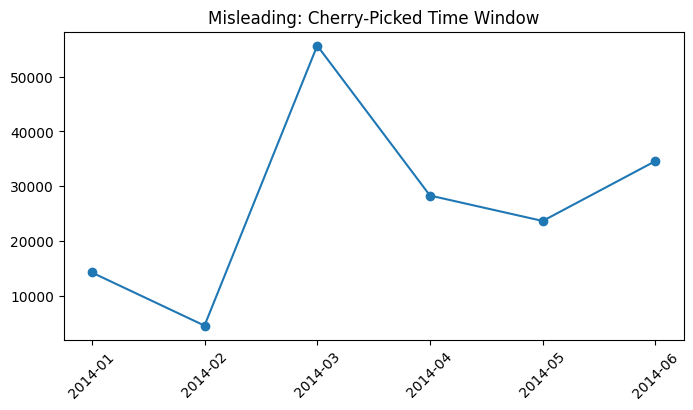

Distortion: a selected time window can hide the surrounding trend.


In [15]:
short_period = monthly_sales.iloc[:6]

plt.figure(figsize=(8,4))
plt.plot(short_period.index, short_period.values, marker="o")
plt.xticks(rotation=45)
plt.title("Misleading: Cherry-Picked Time Window")
plt.show()

print("Distortion: a selected time window can hide the surrounding trend.")


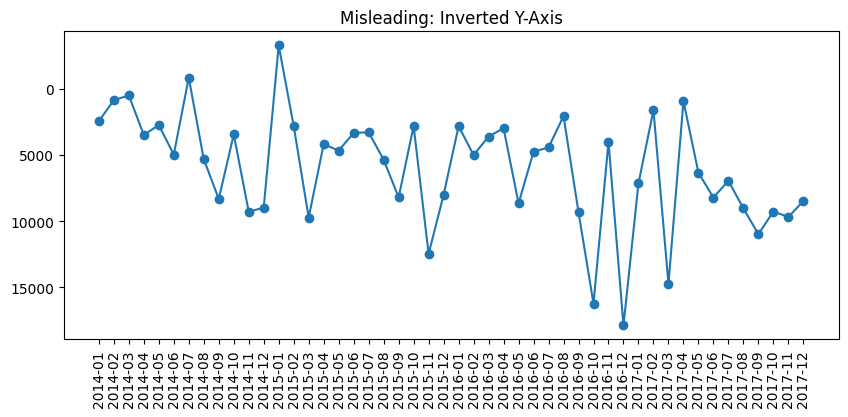

Distortion: an inverted axis can make a decline look like growth.


In [16]:
plt.figure(figsize=(10,4))
plt.plot(monthly_profit.index, monthly_profit.values, marker="o")
plt.gca().invert_yaxis()
plt.xticks(rotation=90)
plt.title("Misleading: Inverted Y-Axis")
plt.show()

print("Distortion: an inverted axis can make a decline look like growth.")


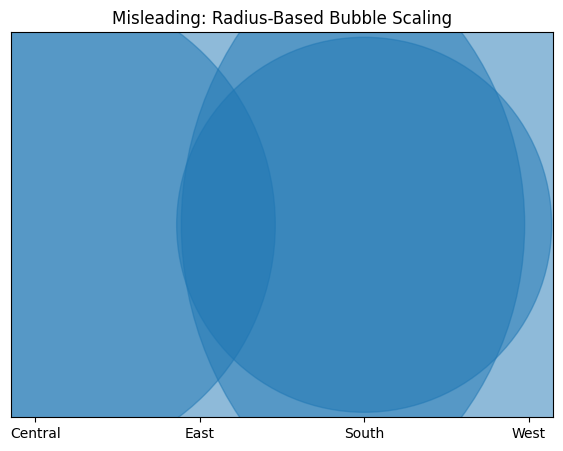

Distortion: scaling radius by value makes the visible area grow too quickly.


In [17]:
values = region_sales.values
sizes = (values / values.max() * 500) ** 2

plt.figure(figsize=(7,5))
plt.scatter(range(len(values)), [1]*len(values), s=sizes, alpha=0.5)
plt.xticks(range(len(values)), region_sales.index)
plt.yticks([])
plt.title("Misleading: Radius-Based Bubble Scaling")
plt.show()

print("Distortion: scaling radius by value makes the visible area grow too quickly.")


## Task 6

Question: Is discounting hurting profit?

The scatter plot is the honest chart because it uses the raw discount and profit values.

The second chart is misleading because it uses averages and a narrow y-axis, which hides the spread of the original data.


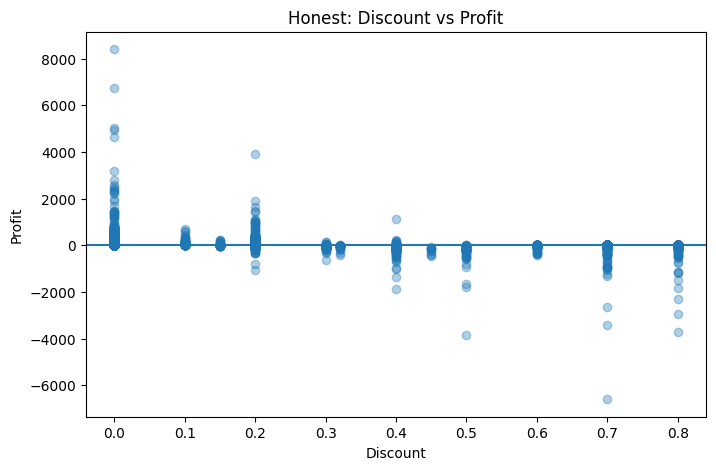

In [18]:
plt.figure(figsize=(8,5))
plt.scatter(df["Discount"], df["Profit"], alpha=0.35)
plt.axhline(0)
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Honest: Discount vs Profit")
plt.show()


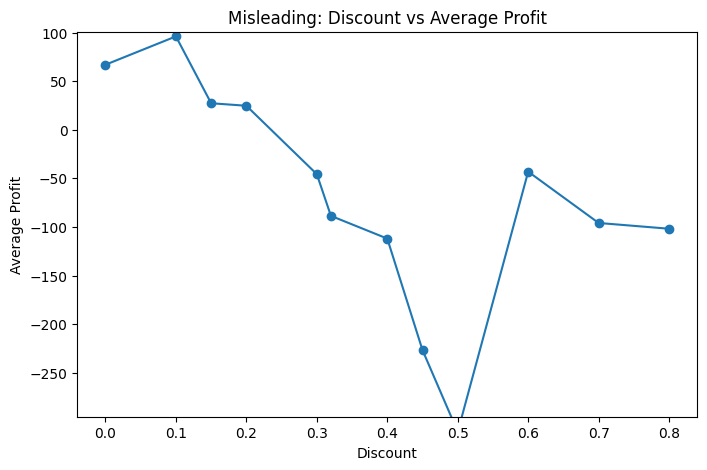

Distortion: averaging hides the spread of the raw data and the narrow axis exaggerates differences.


In [19]:
discount_profit = df.groupby("Discount")["Profit"].mean()

plt.figure(figsize=(8,5))
plt.plot(discount_profit.index, discount_profit.values, marker="o")
plt.ylim(discount_profit.min()*0.95, discount_profit.max()*1.05)
plt.xlabel("Discount")
plt.ylabel("Average Profit")
plt.title("Misleading: Discount vs Average Profit")
plt.show()

print("Distortion: averaging hides the spread of the raw data and the narrow axis exaggerates differences.")


## Conclusion

The appropriate chart depends on the question. Bar charts are useful for category comparisons, line charts for trends, histograms for distributions, scatter plots for relationships, and heatmaps for values across two categories.

Charts should also avoid misleading scales and should not depend on color alone.
